In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# EXPORTAÇÃO

try:
    # encoonding = 'latin1'
    # enconding = 'IBM860'
    # enconding = 'utf-8'
    # enconding = 'iso-8859-1' (pega quase sempre)

    df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', encoding= 'iso-8859-1', sep=';')
    print(df.columns)
    
except Exception as e:
    print(f"Error: {e}")
    exit()




Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [3]:
#AGRUPAR
# Agrupar pelo municipio

df_roubo_veiculos = df[['munic','roubo_veiculo']]
# print(df_roubo_veiculos.head())


In [4]:
# AGRUPAR POR MUNICIPIO
df_roubo_veiculos = df_roubo_veiculos.groupby('munic').sum().reset_index().sort_values(by='roubo_veiculo', ascending=False)
df_roubo_veiculos


,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
...,...,...
66,Rio das Flores,8
58,Porciúncula,7
46,Natividade;Varre-Sai,6
45,Miracema,6


In [13]:
# TRANSFORMAR DATAFRAME EM ARRAY

roubo_veiculo_array = np.array(df_roubo_veiculos['roubo_veiculo'])
amplitude = np.max(roubo_veiculo_array) - np.min(roubo_veiculo_array)
media_roubos = np.mean(roubo_veiculo_array)
mediana_roubos =np.median(roubo_veiculo_array)
# MEDIANA IGUAL Q2
q1 = np.quantile(roubo_veiculo_array,0.25)
q2 = np.quantile(roubo_veiculo_array, 0.50)
q3 = np.quantile(roubo_veiculo_array, 0.75)

print(f'Q2: {q2} -----------Mediana:{mediana_roubos}')

Q2: 247.5 -----------Mediana:247.5


In [14]:
iqr = q3 - q1
# Limite superio - > identificar outliers  acima do q3
limite_superior = q3 + 1.5*iqr

# Limite inferior - > identificar outlier abaixo de q1

limite_inferior = q1 - 1.5*iqr
desvio = np.std(roubo_veiculo_array)
variancia = np.var(roubo_veiculo_array)
distancia_var_media = abs(variancia/media_roubos**2) # ^
cv = desvio/media_roubos
assimetria = df_roubo_veiculos['roubo_veiculo'].skew()
kurt = df_roubo_veiculos['roubo_veiculo'].kurtosis()


In [17]:
print(f'Média:  {media_roubos:,.2f}')
print(f'Mediana:  {mediana_roubos}')
print(f'Min:  {np.min(roubo_veiculo_array)}')
print(f'Limite inferior: {limite_inferior}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite superior:  {limite_superior}')
print(f'Max:  {np.max(roubo_veiculo_array)}')
print(f'Distancia da variancia-Média:  {distancia_var_media:,.2f}')
print(f'Coeficiencia de Variação:  {cv:,.2f}')
print(f'Assimetria:  {assimetria:,.2f}')
print(f'Curtose:  {kurt:,.2f}')


Média:  7,448.24
Mediana:  247.5
Min:  2
Limite inferior: -1366.75
Q1: 47.0
Q3: 989.5
Limite superior:  2403.25
Max:  372584
Distancia da variancia-Média:  28.91
Coeficiencia de Variação:  5.38
Assimetria:  8.62
Curtose:  78.22


In [18]:
df_roubo_outliers_inferiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo']< limite_inferior] 

df_roubo_outliers_superiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] > limite_superior]

In [20]:
# outlier inferiores
# empty :  verifica se o outlier esta vazio 

if df_roubo_outliers_inferiores.empty:
    print(f'Não há outliers inferiores')

else:
    print(df_roubo_outliers_inferiores.sort_values(by='roubo_veiculo', ascending=True))


# outliers Superiores 

if df_roubo_outliers_superiores.empty:
    print(f'Não há outliers superiores')

else:
    print(df_roubo_outliers_superiores.sort_values(by='roubo_veiculo', ascending=False))


Não há outliers inferiores
                    munic  roubo_veiculo
68         Rio de Janeiro         372584
23        Duque de Caxias          62574
78            São Gonçalo          52539
50            Nova Iguaçu          40235
81     São João de Meriti          30151
6            Belford Roxo          22417
48                Niterói          21646
47              Nilópolis          11952
43               Mesquita           7825
27               Itaboraí           5914
29                Itaguaí           3921
38                   Magé           3342
36                  Macaé           3248
13  Campos dos Goytacazes           3022
41                 Maricá           2663


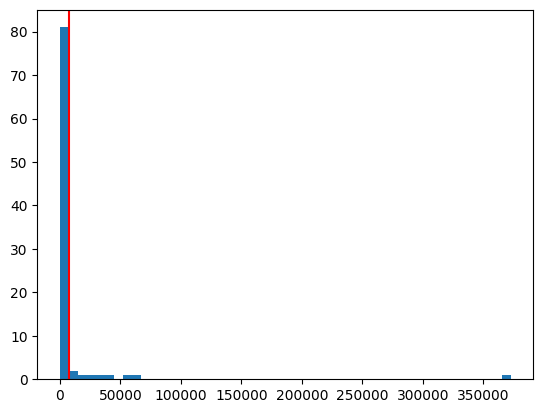

In [23]:
# Histograma

plt.hist(roubo_veiculo_array,bins=50)
plt.axvline(x=media_roubos, color = 'red')

Text(0.5, 1.0, 'Ranking das cidades com outliers Superiores')

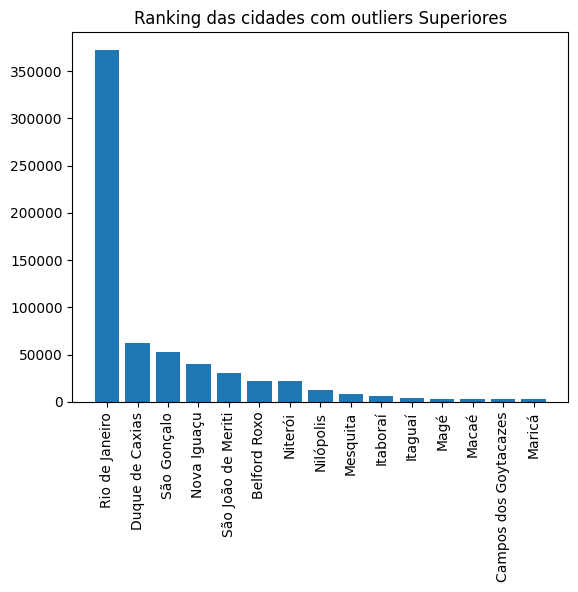

In [27]:
# x, y

plt.bar(df_roubo_outliers_superiores['munic'],df_roubo_outliers_superiores['roubo_veiculo'])
plt.xticks(rotation=90)
plt.title('Ranking das cidades com outliers Superiores')

{'whiskers': [<matplotlib.lines.Line2D at 0x1b46acd8f50>,
 'caps': [<matplotlib.lines.Line2D at 0x1b46acdb710>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b46aa88590>],
 'medians': [<matplotlib.lines.Line2D at 0x1b46acdc550>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b46acdd7d0>],
 'means': [<matplotlib.lines.Line2D at 0x1b46acdcc50>]}

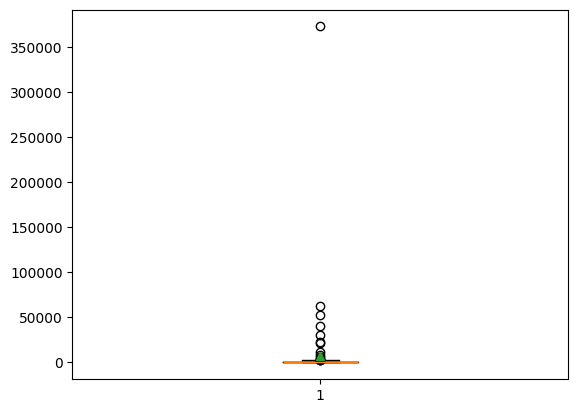

In [31]:
# showmeans( true uo false) -> True marca a media 
# Showfliers ( true uo false) -> para marcar outliers
# 

plt.boxplot(roubo_veiculo_array,vert=True, showmeans=True, showfliers=True)